# Sparse Autoencoder — SAE

**Companion to** [research/07-sparse-autoencoder.md](../research/07-sparse-autoencoder.md)

An SAE is the answer to [superposition](../research/06-superposition-hypothesis.md): learn an
**overcomplete** dictionary ($d_\text{hidden}\gg d_\text{model}$) whose activations are **sparse**, so
the entangled features of a latent unfold into **mono-semantic** directions. Core:
$f=\mathrm{ReLU}(W_\text{enc}(x-b_\text{dec})+b_\text{enc})$, $\hat{x}=W_\text{dec}f+b_\text{dec}$,
minimising reconstruction $+\lambda\lVert f\rVert_1$.

**What we will see:**
1. Synthetic data with **known** ground-truth features in superposition.
2. An SAE **recovers** those features where **PCA cannot**.
3. The reconstruction–sparsity **Pareto frontier** — the trade you must pick.
4. **Activation shrinkage** under L1, and how **TopK** fixes it.
5. **Dead features** — dictionary capacity that never fires.
6. **Feature splitting** — bigger dictionaries split features, so there is no canonical set.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## Experiment 1: Ground-truth features in superposition

**Question:** What does an SAE have to recover?

Unlike a real model, here we *build* the data so the true features are known. We place $n=80$ feature
directions in a $d=40$-dimensional space (so $80>40$ — genuine superposition), and generate each input
as a **sparse** positive combination: on average only one or two features are active at once.

In [2]:
d_model, n_true = 40, 80
p_active = 0.02                                       # each feature active with this prob (sparse)
mag_min = 0.6                                         # active magnitudes in [mag_min, 1] (detectable)
rng = np.random.RandomState(0)
G = rng.randn(d_model, n_true); G /= np.linalg.norm(G, axis=0, keepdims=True)   # true feature dirs
G_t = torch.tensor(G, dtype=torch.float32)

def sample(batch, seed=None):
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    mask = (torch.rand(batch, n_true, generator=g) < p_active).float()
    mag = mag_min + (1 - mag_min) * torch.rand(batch, n_true, generator=g)
    s = mask * mag                                   # sparse activations (batch, n_true)
    x = s @ G_t.t()                                  # (batch, d_model)
    return x, s

x0, s0 = sample(20000, seed=1)
active_per_input = (s0 > 0).sum(1).float()
print(f'features={n_true}, dims={d_model}  ->  {n_true/d_model:.1f}x more features than dimensions')
print(f'mean active features per input = {active_per_input.mean():.1f} (sparse)')

features=80, dims=40  ->  2.0x more features than dimensions
mean active features per input = 1.6 (sparse)


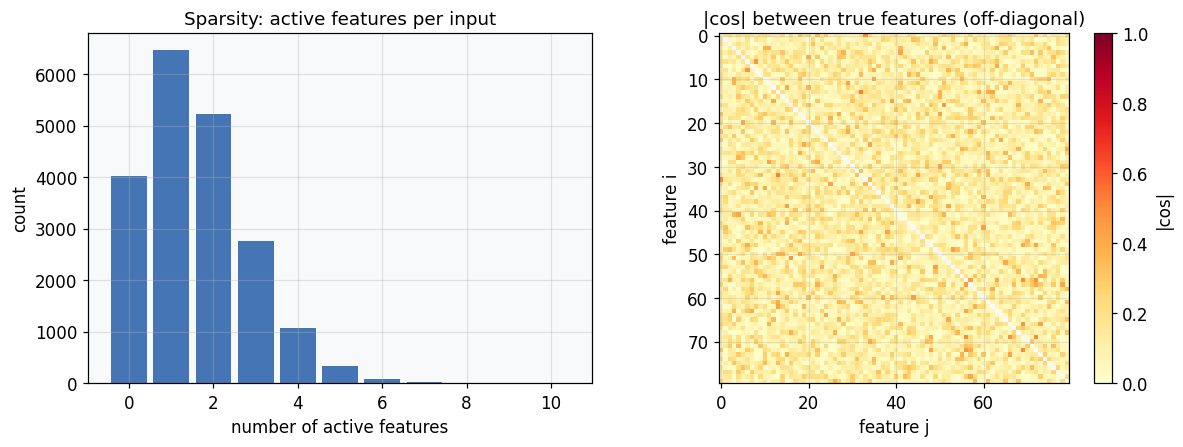

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(active_per_input.numpy(), bins=range(0, 12), color='#4575b4', align='left', rwidth=0.85)
axes[0].set_title('Sparsity: active features per input')
axes[0].set_xlabel('number of active features'); axes[0].set_ylabel('count')
G_gram = np.abs(G.T @ G); np.fill_diagonal(G_gram, np.nan)
im = axes[1].imshow(G_gram, cmap='YlOrRd', vmin=0, vmax=1)
axes[1].set_title('|cos| between true features (off-diagonal)')
axes[1].set_xlabel('feature j'); axes[1].set_ylabel('feature i')
fig.colorbar(im, ax=axes[1], label='|cos|')
plt.tight_layout(); plt.show()

### What you see

Left: only one or two of the 80 features are active in any given input — the data is **sparse**, the
precondition that makes superposition (and its recovery) possible. Right: the 80 feature directions are
**almost orthogonal** — most pairwise $|\cos|$ values are small, but they cannot all be exactly
orthogonal because there are only 40 dimensions. This is precisely the regime
[superposition](../research/06-superposition-hypothesis.md) describes, and the challenge the SAE must
solve: 80 non-orthogonal directions hidden in 40-dimensional activations.

## The SAE we will train

We use the standard architecture from the note. The decoder columns (normalised to unit norm each
step) are the learned dictionary atoms. We support two sparsity mechanisms: an **L1** penalty
(vanilla) and a **TopK** activation (keep the $k$ largest, zero the rest).

In [4]:
class SAE(nn.Module):
    def __init__(self, d_model, d_hidden):
        super().__init__()
        self.W_enc = nn.Parameter(torch.randn(d_hidden, d_model) * 0.1)
        self.b_enc = nn.Parameter(torch.zeros(d_hidden))
        self.W_dec = nn.Parameter(torch.randn(d_model, d_hidden) * 0.1)
        self.b_dec = nn.Parameter(torch.zeros(d_model))
    def encode(self, x, k=None):
        pre = torch.relu((x - self.b_dec) @ self.W_enc.t() + self.b_enc)
        if k is not None:                            # TopK: keep k largest per row
            vals, idx = torch.topk(pre, k, dim=1)
            f = torch.zeros_like(pre).scatter_(1, idx, vals)
            return f
        return pre
    def decode(self, f):
        return f @ self.W_dec.t() + self.b_dec
    def normalize_decoder(self):
        with torch.no_grad():
            self.W_dec.div_(self.W_dec.norm(dim=0, keepdim=True) + 1e-8)

def train_sae(d_hidden, lam=None, k=None, steps=3000, batch=2048, seed=0, lr=1e-3):
    torch.manual_seed(seed)
    sae = SAE(d_model, d_hidden)
    opt = torch.optim.Adam(sae.parameters(), lr=lr)
    for _ in range(steps):
        x, _ = sample(batch)
        sae.normalize_decoder()
        f = sae.encode(x, k=k)
        xh = sae.decode(f)
        loss = ((x - xh) ** 2).sum(1).mean()
        if lam is not None:
            loss = loss + lam * f.abs().sum(1).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    sae.normalize_decoder()
    return sae

def dict_of(sae):
    W = sae.W_dec.detach().numpy()
    return W / np.linalg.norm(W, axis=0, keepdims=True)

print('SAE defined.')

SAE defined.


### What you see

No output yet — this cell defines the encoder/decoder, the two sparsity options, and a trainer that
re-normalises the dictionary atoms to unit length each step (so the L1 penalty acts purely on
activations, and atoms are directly comparable to the true feature directions).

## Experiment 2: SAE recovers features where PCA fails

**Question:** Can a sparse, overcomplete dictionary recover what an orthogonal method cannot?

We train an SAE with $d_\text{hidden}=128$ atoms and, for each of the 80 true features, record the best
$|\cos|$ alignment to any SAE atom — and, for contrast, to any of the 40 PCA components of the same
data.

In [5]:
sae = train_sae(d_hidden=128, lam=3e-2, steps=10000, seed=0)
D = dict_of(sae)                                     # (d_model, 128) unit atoms

# best |cos| of each true feature to any SAE atom
cos_sae = np.abs(G.T @ D)                            # (80, 128)
recov_sae = cos_sae.max(1)

# PCA of the data: d_model orthogonal components
X = x0.numpy(); Xc = X - X.mean(0)
_, _, Vt = np.linalg.svd(Xc, full_matrices=False)    # Vt: (40, 40)
cos_pca = np.abs(G.T @ Vt.T)                          # (80, 40)
recov_pca = cos_pca.max(1)
print(f'mean best-match |cos|   SAE = {recov_sae.mean():.3f}   PCA = {recov_pca.mean():.3f}')
print(f'features recovered >0.9  SAE = {(recov_sae>0.9).sum()}/{n_true}   PCA = {(recov_pca>0.9).sum()}/{n_true}')

mean best-match |cos|   SAE = 0.967   PCA = 0.441
features recovered >0.9  SAE = 79/80   PCA = 0/80


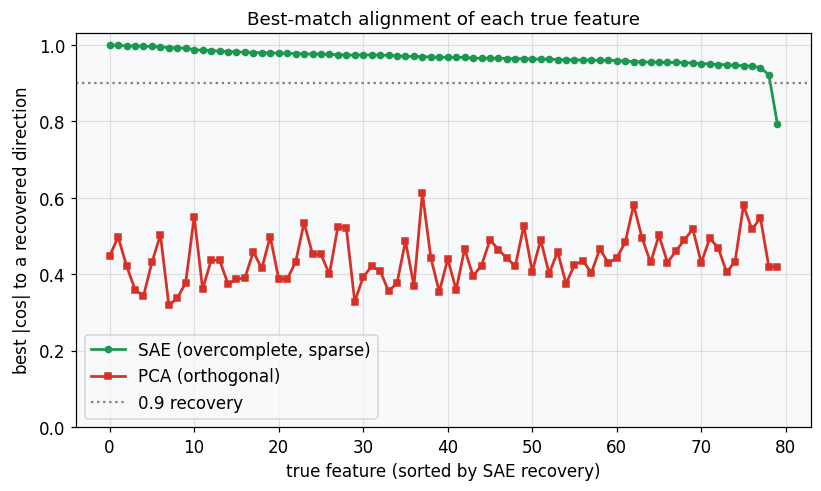

In [6]:
fig, ax = plt.subplots(figsize=(7.6, 4.6))
order = np.argsort(-recov_sae)
ax.plot(recov_sae[order], 'o-', color='#1a9850', ms=4, lw=1.8, label='SAE (overcomplete, sparse)')
ax.plot(recov_pca[order], 's-', color='#d73027', ms=4, lw=1.8, label='PCA (orthogonal)')
ax.axhline(0.9, color='gray', ls=':', label='0.9 recovery')
ax.set_title('Best-match alignment of each true feature')
ax.set_xlabel('true feature (sorted by SAE recovery)')
ax.set_ylabel('best $|\\cos|$ to a recovered direction')
ax.set_ylim(0, 1.03); ax.legend()
plt.tight_layout(); plt.show()

### What you see

The SAE (green) matches almost every true feature with $|\cos|$ near 1 — it has found the 80
non-orthogonal directions hidden in 40 dimensions. PCA (red) cannot: it has only 40 orthogonal
components for 80 features, so its best matches are mediocre and most features go unrecovered.

This is the central result of the note. Swapping the **orthogonality** constraint (PCA) for a
**sparsity** constraint plus an **overcomplete** dictionary (SAE) is exactly what it takes to un-mix
superposition. PCA was provably the wrong tool; the SAE is the right one.

## Experiment 3: The reconstruction–sparsity frontier

**Question:** Is there a free lunch, or must we trade reconstruction against sparsity?

We sweep the L1 strength $\lambda$ and, for each, measure reconstruction error, the average number of
active features (L0), and how well the true features were recovered. There is no single best point —
only a Pareto frontier.

In [7]:
lams = [5e-3, 1e-2, 2e-2, 3e-2, 5e-2, 8e-2, 1.5e-1]
recon, L0, recov, dead = [], [], [], []
xb, _ = sample(8000, seed=7)
for lam in lams:
    s = train_sae(d_hidden=128, lam=lam, steps=6000, seed=1)
    with torch.no_grad():
        f = s.encode(xb); xh = s.decode(f)
        recon.append((((xb - xh) ** 2).sum(1).mean() / (xb ** 2).sum(1).mean()).item())  # normalised MSE
        L0.append((f > 1e-6).float().sum(1).mean().item())
        dead.append(((f > 1e-6).float().sum(0) == 0).float().mean().item())              # never-active atoms
    D = dict_of(s); recov.append(np.abs(G.T @ D).max(1).mean())
for lam, r, l0, rc in zip(lams, recon, L0, recov):
    print(f'lambda={lam:7.4f}  norm-recon-err={r:.3f}  L0={l0:4.1f}  recovery={rc:.3f}')

lambda= 0.0050  norm-recon-err=0.001  L0=45.3  recovery=0.602
lambda= 0.0100  norm-recon-err=0.002  L0=38.0  recovery=0.676
lambda= 0.0200  norm-recon-err=0.008  L0=28.8  recovery=0.773
lambda= 0.0300  norm-recon-err=0.024  L0=12.9  recovery=0.955
lambda= 0.0500  norm-recon-err=0.032  L0= 8.2  recovery=0.987
lambda= 0.0800  norm-recon-err=0.038  L0= 5.4  recovery=0.993
lambda= 0.1500  norm-recon-err=0.052  L0= 4.2  recovery=0.989


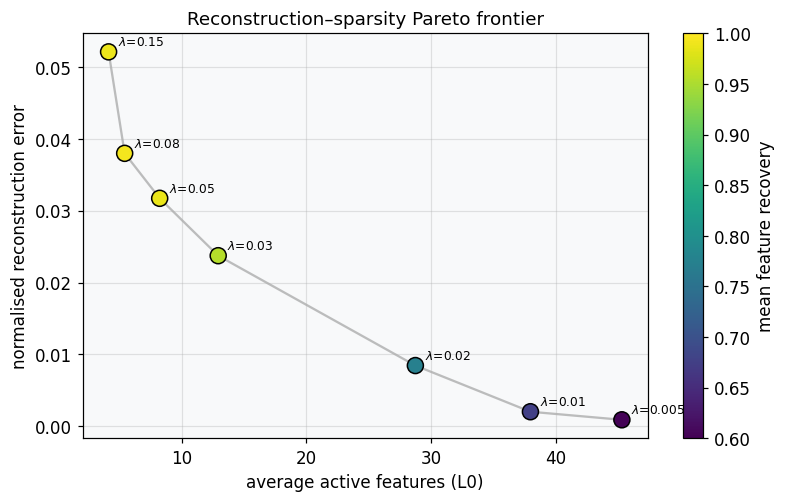

In [8]:
fig, ax = plt.subplots(figsize=(7.4, 4.7))
sc = ax.scatter(L0, recon, c=recov, cmap='viridis', s=110, edgecolor='k', vmin=0.6, vmax=1.0, zorder=3)
ax.plot(L0, recon, '-', color='gray', alpha=0.5, zorder=1)
for lam, l0, r in zip(lams, L0, recon):
    ax.annotate(f'$\\lambda$={lam:g}', (l0, r), textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_title('Reconstruction–sparsity Pareto frontier')
ax.set_xlabel('average active features (L0)'); ax.set_ylabel('normalised reconstruction error')
fig.colorbar(sc, ax=ax, label='mean feature recovery')
plt.tight_layout(); plt.show()

### What you see

The points trace a frontier. At small $\lambda$ (right, $\text{L0}\approx45$) reconstruction is almost
perfect but the code is **dense** and **recovery is poor** ($\approx0.6$): the SAE rebuilds the input
with a blurred, non-sparse basis. Raising $\lambda$ (left, low L0) costs some reconstruction but drives
the code toward the true sparsity ($\approx1$–$2$ active) and **recovery climbs to $\approx0.99$**.

The lesson is sharper than a plain trade-off: chasing the *best reconstruction* (dense) yields the
*worst* features — you must accept slightly worse reconstruction to recover the true sparse basis. And
there is no objectively "correct" $\lambda$; the right operating point depends on the analysis. This is
one of the practical limitations the note flags.

## Experiment 4: Activation shrinkage, and how TopK fixes it

**Question:** Are the SAE's activation magnitudes trustworthy?

The L1 penalty taxes activation *magnitude*, so it pulls estimates **below** their true values —
**shrinkage** (Tibshirani, 1996). We match each true feature to its best L1 atom and to its best TopK
atom, then plot recovered magnitude against the true magnitude.

In [9]:
def matched_pairs(sae, k=None):
    D = dict_of(sae)
    j_star = np.abs(G.T @ D).argmax(1)               # best atom for each true feature
    cosv = np.abs(G.T @ D).max(1)
    xb, sb = sample(6000, seed=11)
    with torch.no_grad():
        f = sae.encode(xb, k=k).numpy()
    true_vals, rec_vals = [], []
    for i in range(n_true):
        if cosv[i] < 0.85:                           # only confidently-matched features
            continue
        m = sb[:, i].numpy() > 1e-6
        true_vals.append(sb[m, i].numpy()); rec_vals.append(f[m, j_star[i]])
    return np.concatenate(true_vals), np.concatenate(rec_vals)

sae_l1 = sae                                          # the L1 SAE from exp 2
sae_topk = train_sae(d_hidden=128, k=4, steps=10000, seed=0)
t_l1, r_l1 = matched_pairs(sae_l1)
t_tk, r_tk = matched_pairs(sae_topk, k=4)
slope_l1 = np.polyfit(t_l1, r_l1, 1)[0]
slope_tk = np.polyfit(t_tk, r_tk, 1)[0]
print(f'L1   recovered/true slope = {slope_l1:.2f}  (<1 => shrinkage)')
print(f'TopK recovered/true slope = {slope_tk:.2f}')

L1   recovered/true slope = 0.85  (<1 => shrinkage)
TopK recovered/true slope = 1.14


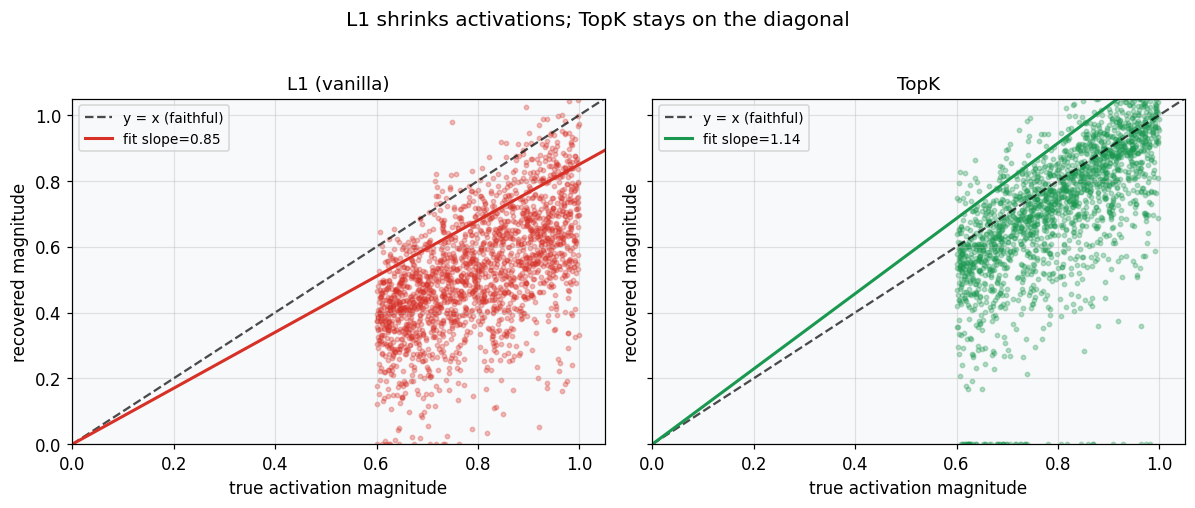

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, t, r, sl, title, col in [(axes[0], t_l1, r_l1, slope_l1, 'L1 (vanilla)', '#d73027'),
                                 (axes[1], t_tk, r_tk, slope_tk, 'TopK', '#1a9850')]:
    idx = np.random.RandomState(0).choice(len(t), min(2000, len(t)), replace=False)
    ax.scatter(t[idx], r[idx], s=8, alpha=0.3, color=col)
    lim = [0, 1.05]
    ax.plot(lim, lim, 'k--', alpha=0.7, label='y = x (faithful)')
    ax.plot(lim, [sl * v for v in lim], color=col, lw=2, label=f'fit slope={sl:.2f}')
    ax.set_title(title); ax.set_xlabel('true activation magnitude'); ax.set_ylabel('recovered magnitude')
    ax.set_xlim(lim); ax.set_ylim(lim); ax.legend(fontsize=9)
fig.suptitle('L1 shrinks activations; TopK stays on the diagonal', y=1.02)
plt.tight_layout(); plt.show()

### What you see

For the **L1** SAE the cloud sits **below** the $y=x$ line — recovered magnitudes are systematically
smaller than the truth (fitted slope $\approx0.84<1$). That is shrinkage: the penalty that buys
sparsity also biases every magnitude downward. The **TopK** SAE, which selects *which* features fire
without taxing their size, shows **no such shrinkage** — its fit sits on or slightly above the diagonal
(slope $\approx1.15$).

This is why the note (and current practice) prefers TopK / JumpReLU / Gated SAEs over vanilla L1 for
any quantitative reading of feature strength — and why Latent-Anything defaults to TopK.

## Experiment 5 (limitation): dead features

**Question:** Does all that dictionary capacity get used?

A **dead feature** is an atom that never activates after training — wasted capacity. Dead atoms appear
when the dictionary is **over-complete** beyond what the data needs. We fix the sparsity and sweep the
dictionary size, counting the fraction of atoms that never fire.

In [11]:
dh_sweep = [96, 128, 200, 320, 480, 640]
dead_frac = []
xb_d, _ = sample(8000, seed=9)
for dh in dh_sweep:
    s = train_sae(d_hidden=dh, lam=5e-2, steps=5000, seed=3)
    with torch.no_grad():
        f = s.encode(xb_d).numpy()
    dead_frac.append(float((f.max(0) < 1e-3).mean()))     # atom never exceeds 1e-3 over the batch
for dh, df in zip(dh_sweep, dead_frac):
    print(f'd_hidden={dh:4d} ({dh/n_true:.1f}x)  dead={df*100:.0f}%')

d_hidden=  96 (1.2x)  dead=0%
d_hidden= 128 (1.6x)  dead=0%
d_hidden= 200 (2.5x)  dead=0%
d_hidden= 320 (4.0x)  dead=8%
d_hidden= 480 (6.0x)  dead=12%
d_hidden= 640 (8.0x)  dead=22%


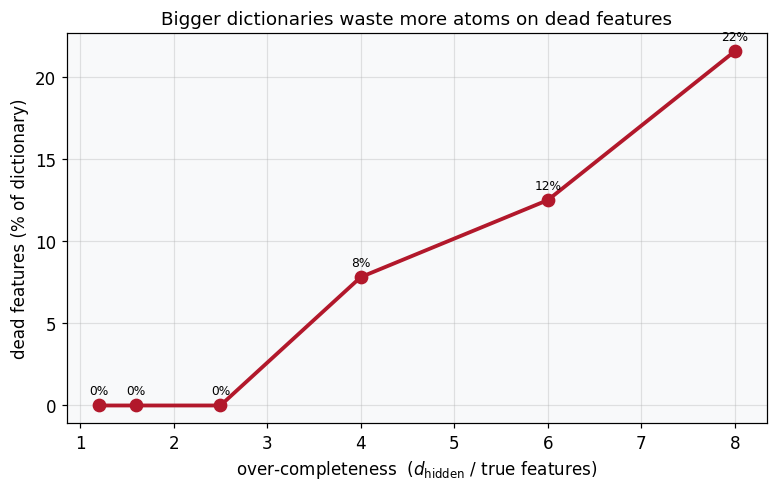

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ratios = [dh / n_true for dh in dh_sweep]
ax.plot(ratios, np.array(dead_frac) * 100, 'o-', color='#b2182b', lw=2.5, ms=8)
ax.set_xlabel('over-completeness  ($d_\\mathrm{hidden}$ / true features)')
ax.set_ylabel('dead features (% of dictionary)')
ax.set_title('Bigger dictionaries waste more atoms on dead features')
for r, dperc in zip(ratios, np.array(dead_frac) * 100):
    ax.annotate(f'{dperc:.0f}%', (r, dperc), textcoords='offset points', xytext=(0, 7), ha='center', fontsize=8)
plt.tight_layout(); plt.show()

### What you see

At modest over-completeness (left) almost every atom is used — the dead fraction is $\approx0$. As the
dictionary grows past what the 80 features need (right, $6$–$8\times$), a rising share of atoms **never
fire** — up to ~22% here. The optimiser has more capacity than the data requires and simply parks the
surplus.

Those dead atoms are dictionary capacity paying for nothing, so the *effective* dictionary is smaller
than it looks. In practice SAEs fight this with **resampling** (re-initialising dead atoms) or
auxiliary losses (Gao et al.) — a real training cost that PCA, with its closed-form solution, does not
have.

## Experiment 6 (limitation): feature splitting → no canonical set

**Question:** If we make the dictionary bigger, do we get *the* features?

We train a much larger dictionary ($d_\text{hidden}=320$, $4\times$ the true count) and count how many
atoms align strongly with **each** true feature. If the dictionary were canonical, each true feature
would get exactly one atom. Instead, features **split** into several near-duplicate atoms.

In [13]:
sae_big = train_sae(d_hidden=320, lam=3e-2, steps=8000, seed=2)
Dbig = dict_of(sae_big)
cosM = np.abs(G.T @ Dbig)                             # (80 true, 320 atoms)
atoms_per_feature = (cosM > 0.9).sum(1)              # how many atoms strongly match each true feature
print(f'dictionary atoms = {Dbig.shape[1]} for {n_true} true features ({Dbig.shape[1]//n_true}x)')
print(f'mean atoms per true feature (|cos|>0.9) = {atoms_per_feature.mean():.2f}')
print(f'features split into >=2 atoms = {(atoms_per_feature>=2).sum()}/{n_true}')

dictionary atoms = 320 for 80 true features (4x)
mean atoms per true feature (|cos|>0.9) = 1.24
features split into >=2 atoms = 20/80


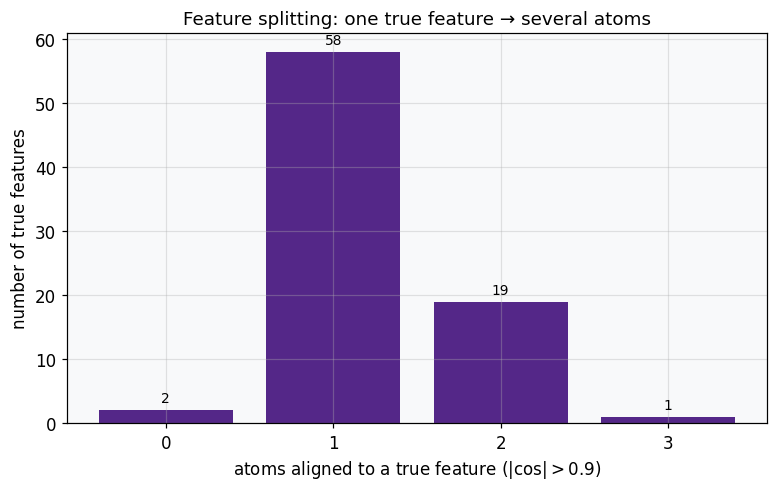

In [14]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
vals, counts = np.unique(atoms_per_feature, return_counts=True)
ax.bar(vals, counts, color='#542788')
for v, c in zip(vals, counts):
    ax.annotate(str(c), (v, c), textcoords='offset points', xytext=(0, 5), ha='center', fontsize=9)
ax.set_xlabel('atoms aligned to a true feature ($|\\cos|>0.9$)')
ax.set_ylabel('number of true features')
ax.set_title('Feature splitting: one true feature → several atoms')
ax.set_xticks(range(int(vals.max()) + 1))
plt.tight_layout(); plt.show()

### What you see

With a $4\times$ dictionary, a substantial fraction of true features (here 20 of 80) are matched by
**two or more** atoms rather than one — the SAE has **split** them into near-duplicate variants. The
dictionary size is a free hyperparameter, and the "features" it returns depend on that choice; there is
no size at which it converges to a unique, canonical set.

This is the note's deepest caveat: recovering *a* sparse basis is not the same as recovering *the*
features the model uses. SAE outputs are a useful lens, not ground truth — which is why any feature
must still be validated by [causal intervention](../research/04-causal-intervention-vs-observational.md)
before it is trusted.

## Summary / Key Takeaways

- **Exp 1** — Sparse data with 80 near-orthogonal features in 40 dimensions: the superposition an SAE
  must un-mix.
- **Exp 2** — An overcomplete, sparse SAE **recovers** the true features ($|\cos|\approx1$) where PCA's
  orthogonal components **cannot** — orthogonality out, sparsity in.
- **Exp 3** — Reconstruction vs sparsity is a **Pareto frontier**; recovery peaks at intermediate
  $\lambda$, and there is no objectively correct operating point.
- **Exp 4** — **L1 shrinks** activation magnitudes (slope $<1$); **TopK** removes the bias — prefer
  TopK / JumpReLU for quantitative work.
- **Exp 5** — Over-complete dictionaries grow **dead features** (atoms that never fire, ~22% at 8×):
  wasted capacity needing resampling, a cost PCA avoids.
- **Exp 6** — Bigger dictionaries cause **feature splitting**: no canonical set, so SAE features are a
  lens to be validated causally, not ground truth.
